## Día 3 · Morosidad: leer un ciclo de crédito con datos de la Reserva Federal

Notebook que acompaña al post del reto *IA aplicada a finanzas*. Descarga desde FRED las
tasas de morosidad que publica la Junta de la Reserva Federal para todos los bancos
comerciales de EE. UU., las ubica en su historia y las cruza con las recesiones.

In [1]:
from datetime import date
from io import StringIO
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

DATA = Path("../data")
DATA.mkdir(exist_ok=True)

# Series trimestrales, desestacionalizadas, todos los bancos comerciales (fuente: Junta de la Fed)
SERIES = {
    "DRALACBS": "Total de préstamos",
    "DRCCLACBS": "Tarjetas de crédito",
    "DRCLACBS": "Consumo (total)",
    "DRSFRMACBS": "Hipotecas residenciales",
    "DRCRELEXFACBS": "Inmobiliario comercial",
    "DRBLACBS": "Comerciales e industriales",
}
CASTIGOS = "CORCCACBS"     # tasa de castigos netos de tarjetas
RECESION = "USREC"         # indicador mensual de recesión (NBER)
DESDE = "1991-01-01"       # inicio común de todas las series

# --- Paleta del portafolio ---
SUPERFICIE = "#fcfcfb"
TINTA, TINTA_2, TINTA_MUTED = "#0b0b0b", "#52514e", "#898781"
GRILLA, EJE, SOMBRA = "#e1e0d9", "#c3c2b7", "#ecebe6"
AZUL, NARANJA, NEUTRO = "#2a78d6", "#eb6834", "#a3a19a"
mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10, "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.edgecolor": EJE,
    "axes.linewidth": 0.8, "axes.titlesize": 11.5, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA_MUTED, "ytick.color": TINTA_MUTED, "xtick.labelcolor": TINTA_2,
    "ytick.labelcolor": TINTA_2, "grid.color": GRILLA, "grid.linewidth": 0.8,
    "legend.frameon": False, "lines.linewidth": 2.0, "figure.dpi": 130, "savefig.bbox": "tight",
})


def num(x, dec=2):
    return f"{x:,.{dec}f}".replace(",", "\x00").replace(".", ",").replace("\x00", ".")


def trimestre(fecha):
    return f"{fecha.year}T{fecha.quarter}"

## 1. Descargar las series

FRED permite bajar cualquier serie como CSV desde
`https://fred.stlouisfed.org/graph/fredgraph.csv?id=SERIE`, sin registro. Para un uso
intensivo conviene la API oficial, que requiere una clave gratuita.

Las cifras de la Fed **se revisan**: un trimestre publicado puede cambiar en la
publicación siguiente. Por eso se guarda la fecha de descarga junto con los datos.

In [2]:
def bajar(serie):
    r = requests.get("https://fred.stlouisfed.org/graph/fredgraph.csv", params={"id": serie}, timeout=60)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), index_col=0, parse_dates=True)
    return df[serie]

tasas = pd.concat({s: bajar(s) for s in SERIES}, axis=1, sort=True).loc[DESDE:]
castigos = bajar(CASTIGOS).loc[DESDE:]
recesion = bajar(RECESION).loc[DESDE:]

descarga = date.today().isoformat()
(tasas.join(castigos).assign(fecha_descarga=descarga)
      .to_csv(DATA / "morosidad_fred.csv", index_label="trimestre_inicio"))
print(f"Descargado el {descarga}: {len(tasas)} trimestres, de {trimestre(tasas.index[0])} "
      f"a {trimestre(tasas.index[-1])}")

Descargado el 2026-10-03: 142 trimestres, de 1991T1 a 2026T2


## 2. Qué mide exactamente el indicador

Según la Reserva Federal, un préstamo está en mora si tiene **30 días o más de atraso y
sigue devengando intereses, o si está en estado de no devengo** (*nonaccrual*). La tasa
es el monto de préstamos en mora de una categoría dividido entre el saldo total de esa
categoría. Los datos salen de los reportes regulatorios trimestrales que presenta cada
banco (*Call Reports*).

FRED fecha cada trimestre en su primer día: la observación `2026-04-01` corresponde al
segundo trimestre de 2026, que en este notebook se escribe 2026T2.

In [3]:
#| label: tbl-resumen
filas = []
for s, nombre in SERIES.items():
    x = tasas[s].dropna()
    ultimo = x.iloc[-1]
    filas.append({
        "Categoría": nombre,
        f"Último ({trimestre(x.index[-1])})": num(ultimo) + " %",
        "Promedio desde 1991": num(x.mean()) + " %",
        "2019T4 (prepandemia)": num(x.loc["2019-10-01"]) + " %",
        "Máximo": f"{num(x.max())} % ({trimestre(x.idxmax())})",
        "Percentil histórico": f"{(x < ultimo).mean() * 100:.0f}",
    })
pd.DataFrame(filas).style.hide(axis="index")

Categoría,Último (2026T2),Promedio desde 1991,2019T4 (prepandemia),Máximo,Percentil histórico
Total de préstamos,"1,42 %","2,79 %","1,41 %","7,35 % (2010T1)",8
Tarjetas de crédito,"2,85 %","3,69 %","2,61 %","6,77 % (2009T2)",31
Consumo (total),"2,62 %","3,00 %","2,35 %","4,85 % (2009T2)",30
Hipotecas residenciales,"1,86 %","3,72 %","2,34 %","11,48 % (2010T1)",20
Inmobiliario comercial,"1,53 %","3,07 %","0,67 %","11,99 % (1991T1)",42
Comerciales e industriales,"1,27 %","2,08 %","1,09 %","6,41 % (1991T2)",32


El **percentil histórico** dice qué fracción de los trimestres desde 1991 tuvo una tasa
menor que la actual: 8 significa que solo el 8 % de los trimestres estuvo por debajo.

In [4]:
def sombrear_recesiones(ax):
    inicio = None
    for fecha, valor in recesion.items():
        if valor == 1 and inicio is None:
            inicio = fecha
        elif valor == 0 and inicio is not None:
            ax.axvspan(inicio, fecha, color=SOMBRA, zorder=0, linewidth=0)
            inicio = None
    if inicio is not None:
        ax.axvspan(inicio, recesion.index[-1], color=SOMBRA, zorder=0, linewidth=0)

def ejes_limpios(ax):
    ax.yaxis.grid(True, alpha=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f} %")

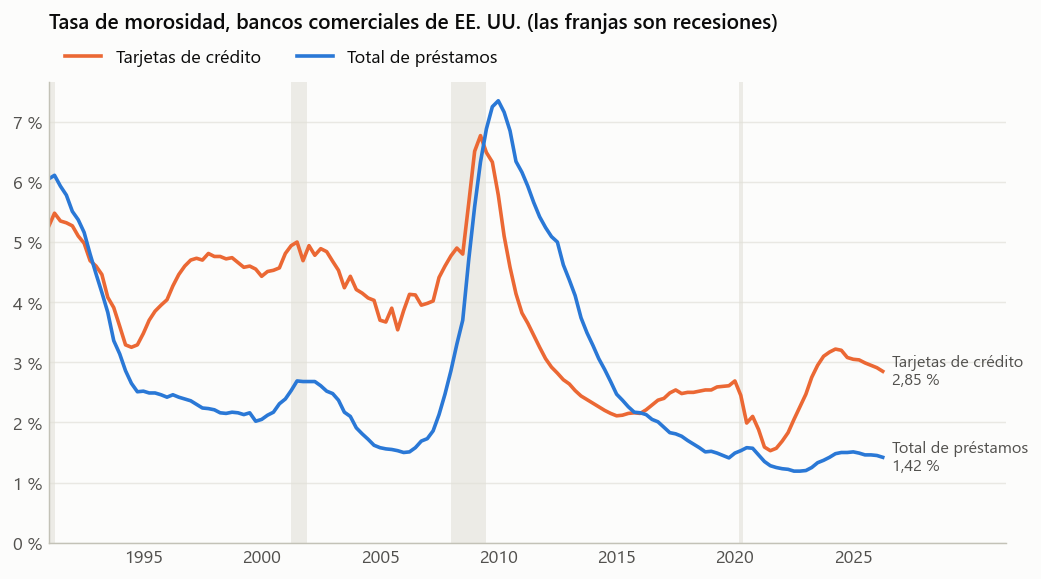

In [5]:
#| label: fig-tarjetas
fig, ax = plt.subplots(figsize=(9.5, 4.6))
sombrear_recesiones(ax)
for s, color in [("DRCCLACBS", NARANJA), ("DRALACBS", AZUL)]:
    ax.plot(tasas.index, tasas[s], color=color, label=SERIES[s])
    ax.text(tasas.index[-1] + pd.Timedelta(days=150), tasas[s].iloc[-1],
            f"{SERIES[s]}\n{num(tasas[s].iloc[-1])} %", va="center", fontsize=9, color=TINTA_2)
ax.set_xlim(tasas.index[0], tasas.index[-1] + pd.Timedelta(days=1900))
ax.set_xticks(pd.to_datetime([f"{a}-01-01" for a in range(1995, 2030, 5)]))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y"))
ax.set_ylim(0, None)
ejes_limpios(ax)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2)
ax.set_title("Tasa de morosidad, bancos comerciales de EE. UU. (las franjas son recesiones)", pad=30)
plt.show()

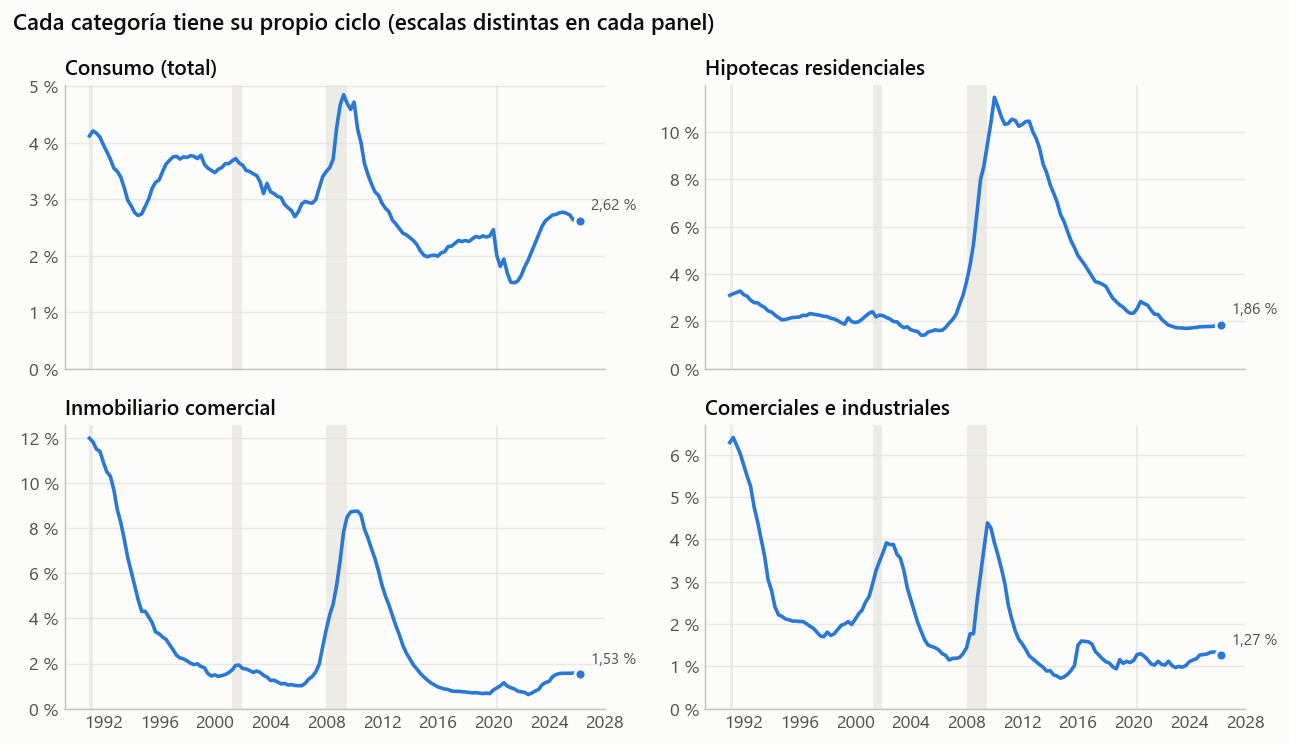

In [6]:
#| label: fig-categorias
otras = ["DRCLACBS", "DRSFRMACBS", "DRCRELEXFACBS", "DRBLACBS"]
fig, ejes = plt.subplots(2, 2, figsize=(10, 5.8), sharex=True)
for ax, s in zip(ejes.flat, otras):
    sombrear_recesiones(ax)
    ax.plot(tasas.index, tasas[s], color=AZUL)
    ax.plot(tasas.index[-1], tasas[s].iloc[-1], "o", color=AZUL, markersize=6,
            markeredgecolor=SUPERFICIE, markeredgewidth=1.5)
    ax.annotate(f"{num(tasas[s].iloc[-1])} %", (tasas.index[-1], tasas[s].iloc[-1]),
                xytext=(6, 6), textcoords="offset points", fontsize=8.5, color=TINTA_2)
    ax.set_title(SERIES[s])
    ax.set_ylim(0, None)
    ejes_limpios(ax)
fig.suptitle("Cada categoría tiene su propio ciclo (escalas distintas en cada panel)",
             x=0.01, ha="left", fontsize=12.5, fontweight="600")
fig.tight_layout()
plt.show()

## 3. La mora anticipa las pérdidas

Un préstamo primero se atrasa y, si no se recupera, se **castiga** (se reconoce como
pérdida). Por eso la mora debería adelantarse a los castigos. Se mide comparando la
morosidad de tarjetas con los castigos de tarjetas desplazados entre 0 y 4 trimestres.

In [7]:
#| label: out-rezago
mora_tc = tasas["DRCCLACBS"]
corr = {k: mora_tc.corr(castigos.shift(-k)) for k in range(5)}
for k, c in corr.items():
    print(f"Castigos {k} trimestre(s) después: correlación {num(c)}")
mejor = max(corr, key=corr.get)
print(f"\nLa mora de tarjetas se alinea mejor con los castigos de {mejor} trimestre(s) después.")

Castigos 0 trimestre(s) después: correlación 0,75
Castigos 1 trimestre(s) después: correlación 0,80
Castigos 2 trimestre(s) después: correlación 0,81
Castigos 3 trimestre(s) después: correlación 0,78
Castigos 4 trimestre(s) después: correlación 0,75

La mora de tarjetas se alinea mejor con los castigos de 2 trimestre(s) después.


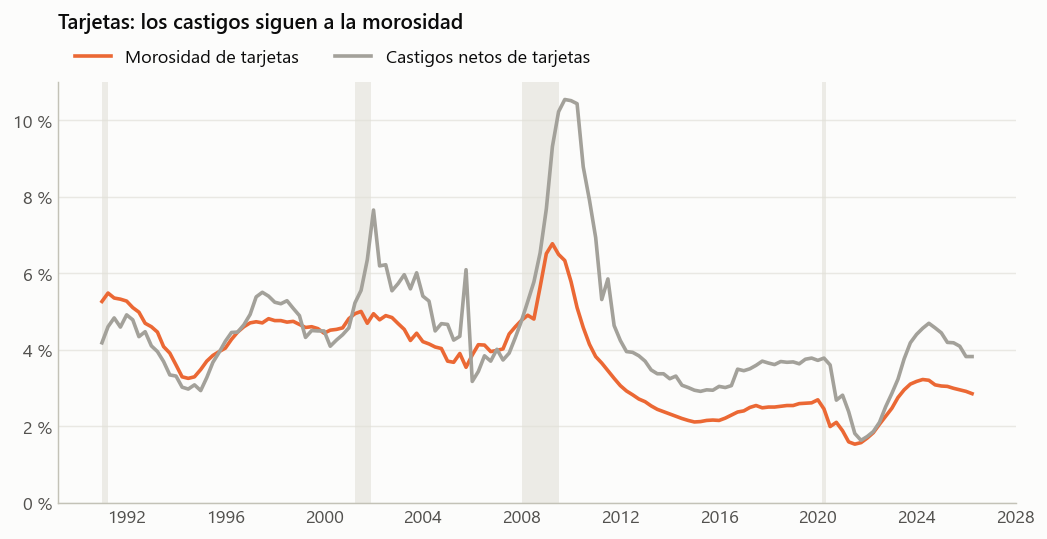

In [8]:
#| label: fig-castigos
fig, ax = plt.subplots(figsize=(9.5, 4.2))
sombrear_recesiones(ax)
ax.plot(mora_tc.index, mora_tc, color=NARANJA, label="Morosidad de tarjetas")
ax.plot(castigos.index, castigos, color=NEUTRO, label="Castigos netos de tarjetas")
ax.set_ylim(0, None)
ejes_limpios(ax)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2)
ax.set_title("Tarjetas: los castigos siguen a la morosidad", pad=30)
plt.show()